# 02 — Результаты обучения LoRA

Визуализация 12 прогонов LoRA-fine-tuning (E1-E4 × 3 автора) + 3 instruction-tuning (E5) прогона.

**Эксперименты:**

| Код | r | α | lr | epochs | Обуч. параметров | % от базы |
|-----|---|---|----|--------|------------------:|----------:|
| E1_default | 8 | 16 | 2e-4 | 5 | 811 008 | 0.49% |
| E2_low_rank | 4 | 8 | 2e-4 | 5 | 405 504 | 0.25% |
| E3_high_rank | 16 | 32 | 2e-4 | 5 | 1 622 016 | 0.98% |
| E4_long_train | 8 | 16 | 1e-4 | 10 | 811 008 | 0.49% |
| E5_instruct | 16 | 32 | 2e-4 | 5 | 1 622 016 | 0.98% |

База: rugpt3small 164M параметров.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['font.family'] = 'DejaVu Sans'

BASE = Path('..')
FIG_DIR = BASE / 'notebooks' / 'figures' / 'training'
FIG_DIR.mkdir(parents=True, exist_ok=True)

AUTHOR_RU = {'dostoevsky': 'Достоевский', 'chekhov': 'Чехов', 'bulgakov': 'Булгаков'}
AUTHORS = ['dostoevsky', 'chekhov', 'bulgakov']
EXP_ORDER = ['E1_default', 'E2_low_rank', 'E3_high_rank', 'E4_long_train']
EXP_RU = {
    'E1_default':    'E1 (r=8)',
    'E2_low_rank':   'E2 (r=4)',
    'E3_high_rank':  'E3 (r=16)',
    'E4_long_train': 'E4 (10 эпох)',
    'E5_instruct':   'E5 (instruct)',
}
PALETTE = {'dostoevsky': '#C0392B', 'chekhov': '#2980B9', 'bulgakov': '#27AE60'}

## 1. Загрузка и таблица результатов

In [2]:
def load_results(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

prose = load_results(BASE / 'models' / 'experiment_results.jsonl')
instruct = load_results(BASE / 'models' / 'experiment_results_instruct.jsonl')
all_results = pd.DataFrame(prose + instruct)
all_results['perplexity_eval'] = np.exp(all_results['eval_loss'])

# Сводная таблица — удобно для диплома
pivot_eval = all_results.pivot(index='author', columns='experiment', values='eval_loss').round(3)
pivot_eval = pivot_eval.reindex(index=AUTHORS)
pivot_eval.index = [AUTHOR_RU[a] for a in pivot_eval.index]
print('Eval loss (чем меньше — тем лучше):')
display(pivot_eval)
pivot_eval.to_csv(FIG_DIR / 'eval_loss_table.csv')

pivot_ppl = all_results.pivot(index='author', columns='experiment', values='perplexity_eval').round(2)
pivot_ppl = pivot_ppl.reindex(index=AUTHORS)
pivot_ppl.index = [AUTHOR_RU[a] for a in pivot_ppl.index]
print('\nPerplexity (exp eval_loss):')
display(pivot_ppl)

Eval loss (чем меньше — тем лучше):


experiment,E1_default,E2_low_rank,E3_high_rank,E4_long_train,E5_instruct
Достоевский,3.367,3.383,3.350,3.368,3.594
Чехов,3.160,3.177,3.140,3.160,3.650
Булгаков,3.310,3.320,3.296,3.309,3.785



Perplexity (exp eval_loss):


experiment,E1_default,E2_low_rank,E3_high_rank,E4_long_train,E5_instruct
Достоевский,29.00,29.45,28.49,29.01,36.36
Чехов,23.56,23.97,23.11,23.57,38.46
Булгаков,27.38,27.67,27.01,27.35,44.03


## 2. Сравнение eval_loss — 4 конфигурации на прозе

Здесь сравниваем только E1-E4 (все обучались на сыром корпусе, eval на том же распределении). E5 отдельно.

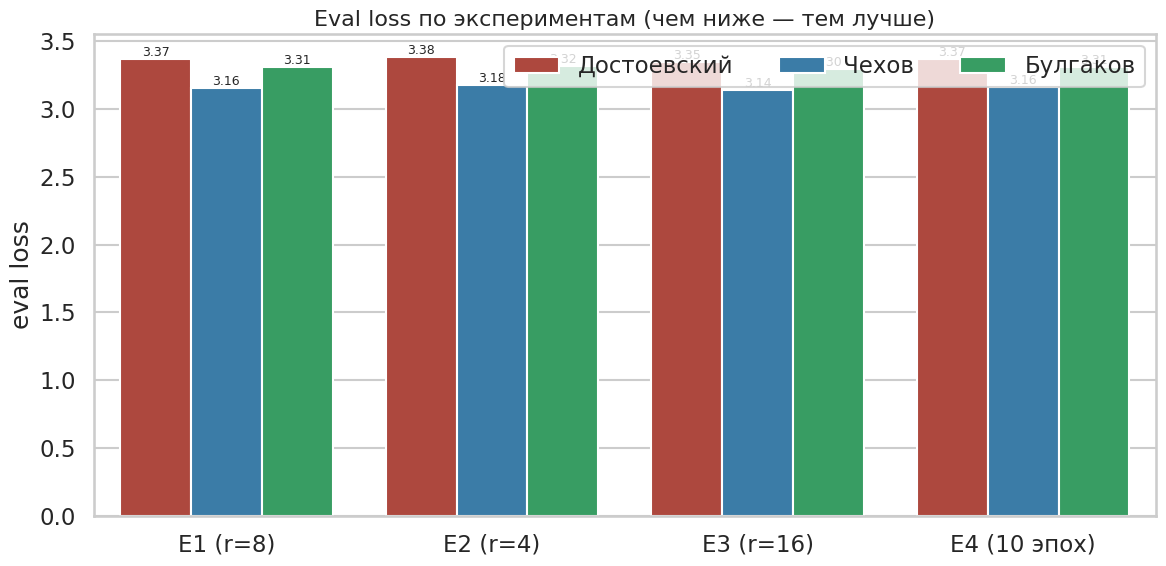

In [3]:
prose_df = all_results[all_results['experiment'].isin(EXP_ORDER)].copy()
prose_df['exp_label'] = prose_df['experiment'].map(EXP_RU)
prose_df['author_label'] = prose_df['author'].map(AUTHOR_RU)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=prose_df, x='exp_label', y='eval_loss', hue='author_label',
            palette=[PALETTE[a] for a in AUTHORS],
            order=[EXP_RU[e] for e in EXP_ORDER],
            hue_order=[AUTHOR_RU[a] for a in AUTHORS], ax=ax)
ax.set_title('Eval loss по экспериментам (чем ниже — тем лучше)', fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('eval loss')
ax.legend(title='', loc='upper right', ncols=3)
# Аннотации значений
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.2f}', (p.get_x() + p.get_width()/2, h),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eval_loss_by_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Эффект ранга LoRA (r=4 / r=8 / r=16)

E2 (r=4) → E1 (r=8) → E3 (r=16) — фиксируем всё кроме ранга.

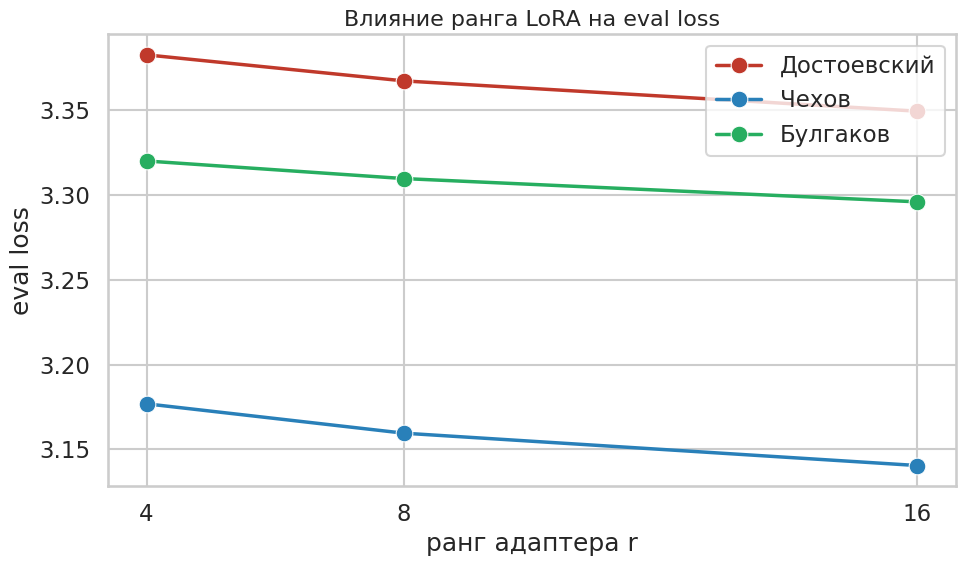

In [4]:
rank_experiments = ['E2_low_rank', 'E1_default', 'E3_high_rank']
rank_df = all_results[all_results['experiment'].isin(rank_experiments)].copy()
rank_df['r_label'] = rank_df['r'].map({4: 'r=4', 8: 'r=8', 16: 'r=16'})
rank_df['author_label'] = rank_df['author'].map(AUTHOR_RU)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=rank_df, x='r', y='eval_loss', hue='author_label', marker='o',
             markersize=12, linewidth=2.5,
             palette=[PALETTE[a] for a in AUTHORS],
             hue_order=[AUTHOR_RU[a] for a in AUTHORS], ax=ax)
ax.set_title('Влияние ранга LoRA на eval loss', fontsize=16)
ax.set_xlabel('ранг адаптера r')
ax.set_ylabel('eval loss')
ax.set_xticks([4, 8, 16])
ax.legend(title='', loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lora_rank_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Объём обучаемых параметров

Главное преимущество LoRA — обучаем всего ~0.25-0.98% параметров вместо полного fine-tuning.

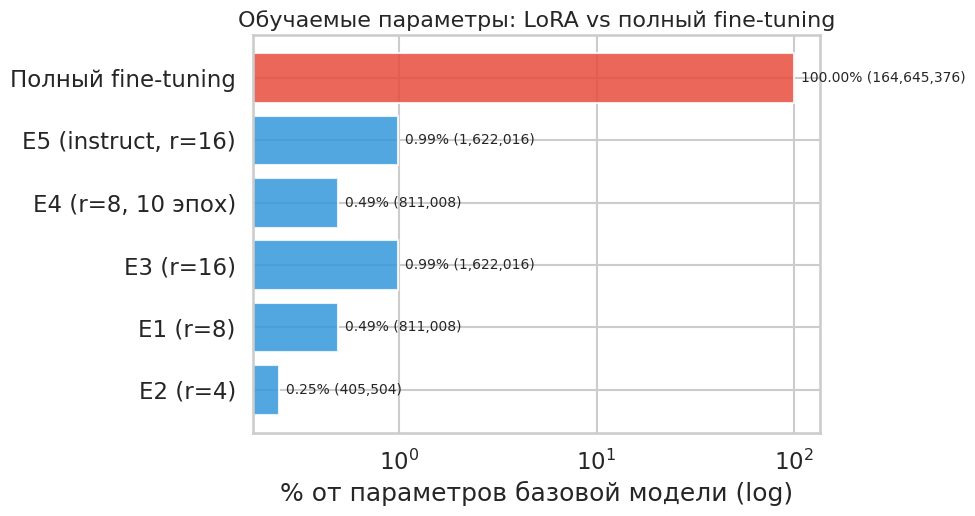

In [5]:
BASE_PARAMS = 164_645_376
params_data = [
    ('E2 (r=4)', 405_504),
    ('E1 (r=8)', 811_008),
    ('E3 (r=16)', 1_622_016),
    ('E4 (r=8, 10 эпох)', 811_008),
    ('E5 (instruct, r=16)', 1_622_016),
    ('Полный fine-tuning', BASE_PARAMS),
]
df = pd.DataFrame(params_data, columns=['config', 'params'])
df['pct'] = df['params'] / BASE_PARAMS * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ['#3498DB'] * 5 + ['#E74C3C']
bars = ax.barh(df['config'], df['pct'], color=colors, alpha=0.85)
ax.set_xscale('log')
ax.set_xlabel('% от параметров базовой модели (log)')
ax.set_title('Обучаемые параметры: LoRA vs полный fine-tuning', fontsize=16)
for bar, (_, row) in zip(bars, df.iterrows()):
    ax.annotate(f"{row['pct']:.2f}% ({row['params']:,})",
                (row['pct'], bar.get_y() + bar.get_height()/2),
                va='center', fontsize=10, xytext=(5, 0), textcoords='offset points')
plt.tight_layout()
plt.savefig(FIG_DIR / 'trainable_params.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. E5_instruct — отдельно

Eval loss E5 **нельзя напрямую сравнивать** с E1-E4: E5 обучался на synthetic Q&A с маскированием префикса (loss только на ответе), E1-E4 — на сыром тексте. Показываем самостоятельно.

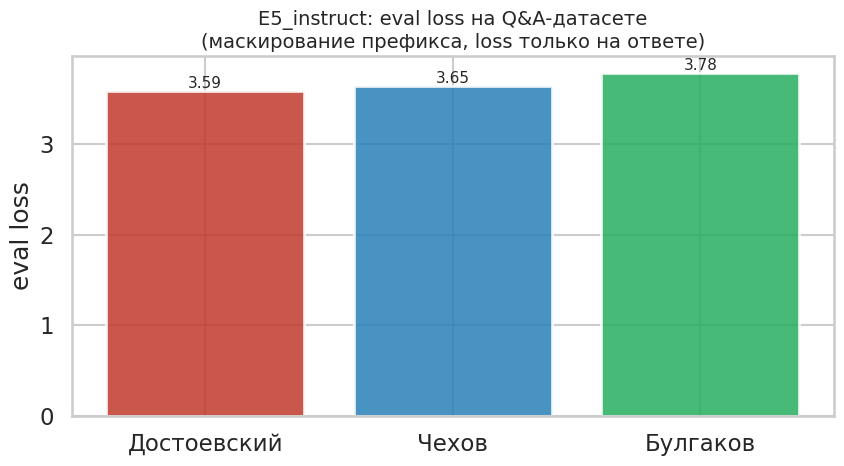

,author_label,train_loss,eval_loss,train_samples,eval_samples
12,Достоевский,3.927,3.594,450,50
13,Чехов,3.944,3.650,447,50
14,Булгаков,4.040,3.785,450,50


In [6]:
e5 = all_results[all_results['experiment'] == 'E5_instruct'].copy()
e5['author_label'] = e5['author'].map(AUTHOR_RU)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(e5['author_label'], e5['eval_loss'],
              color=[PALETTE[a] for a in e5['author']], alpha=0.85,
              edgecolor='white', linewidth=2)
ax.set_title('E5_instruct: eval loss на Q&A-датасете\n(маскирование префикса, loss только на ответе)',
             fontsize=14)
ax.set_ylabel('eval loss')
for b, v in zip(bars, e5['eval_loss']):
    ax.annotate(f'{v:.2f}', (b.get_x() + b.get_width()/2, v),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'e5_instruct_loss.png', dpi=150, bbox_inches='tight')
plt.show()
display(e5[['author_label', 'train_loss', 'eval_loss', 'train_samples', 'eval_samples']].round(3))

---
**Итоги:**
- **E3_high_rank (r=16)** — победитель по eval_loss у всех трёх авторов
- **Увеличение ранга r=4→r=16** даёт монотонное улучшение (~0.5-0.6% относительно)
- **10 эпох (E4) не лучше 5** — модель сходится к 5-й эпохе
- **LoRA обучает <1%** параметров — в 100 раз дешевле полного fine-tuning
- **E5_instruct** — отдельный task, сравнение через качество ответов (этап D)